# SAE feature emergence: findings

We ask: **when and how do SAE-discovered features emerge and stabilize during training**, and **do they causally contribute to the model?** This notebook loads the pipeline outputs and states what we find (stability + ablation), not just the code.

## Setup

In [8]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt

# Project root: either cwd (if run from sae_feature_emergence) or cwd/sae_feature_emergence
ROOT = Path.cwd() if (Path.cwd() / "config.py").exists() else Path.cwd() / "sae_feature_emergence"
sys.path.insert(0, str(ROOT))
from config import RESULTS_DIR, CHECKPOINTS_DIR
RESULTS_DIR = Path(RESULTS_DIR)
CHECKPOINTS_DIR = Path(CHECKPOINTS_DIR)

In [9]:
# Paths ready (RESULTS_DIR, CHECKPOINTS_DIR)

## Training (loss and checkpoints)

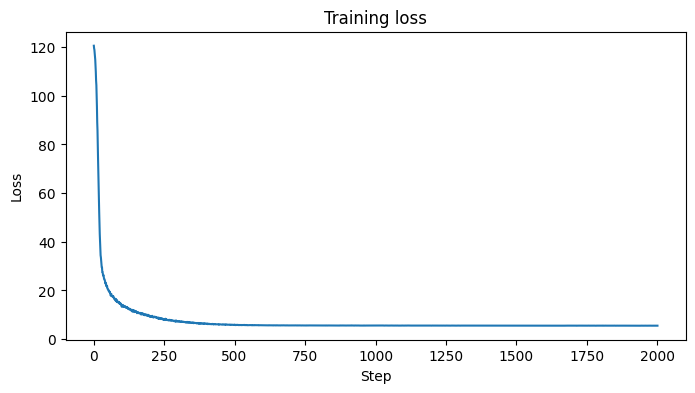

In [10]:
loss_path = RESULTS_DIR / "loss_history.json"
if loss_path.exists():
    with open(loss_path) as f:
        loss_history = json.load(f)
    steps = [x["step"] for x in loss_history]
    losses = [x["loss"] for x in loss_history]
    plt.figure(figsize=(8, 4))
    plt.plot(steps, losses)
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title("Training loss")
    plt.show()
else:
    print("No loss_history.json yet. Run make sae-train.")

### Checkpoints

In [11]:
if CHECKPOINTS_DIR.exists():
    ckpts = sorted(CHECKPOINTS_DIR.glob("step_*.pt"))
    print(f"Checkpoints: {[p.name for p in ckpts]}")
else:
    print("No checkpoints dir yet. Run make sae-train.")

Checkpoints: ['step_100.pt', 'step_1000.pt', 'step_1300.pt', 'step_1600.pt', 'step_200.pt', 'step_2000.pt', 'step_400.pt', 'step_600.pt', 'step_800.pt']


## Stability (similarity and drift)

  100 -> 200: similarity = 0.2936, drift = 0.7064
  200 -> 400: similarity = 0.2811, drift = 0.7189
  400 -> 600: similarity = 0.2794, drift = 0.7206
  600 -> 800: similarity = 0.2858, drift = 0.7142
  800 -> 1000: similarity = 0.2922, drift = 0.7078
  1000 -> 1300: similarity = 0.2947, drift = 0.7053
  1300 -> 1600: similarity = 0.3150, drift = 0.6850
  1600 -> 2000: similarity = 0.3378, drift = 0.6622


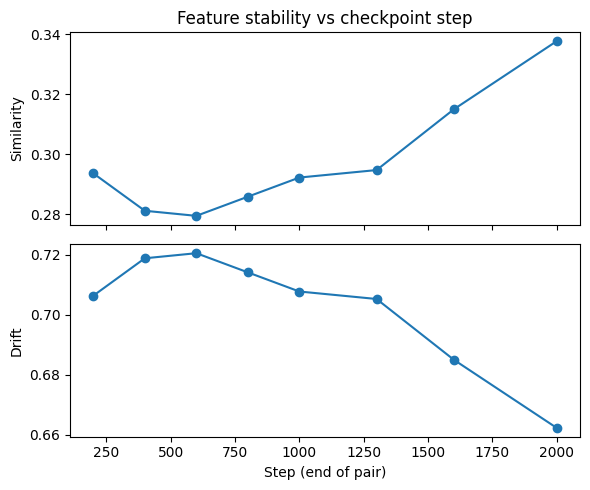

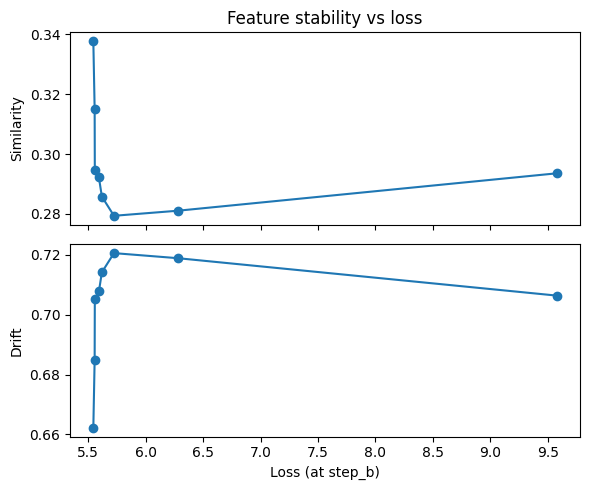

In [12]:
from plots import plot_stability_vs_step, plot_stability_vs_loss

stability_path = RESULTS_DIR / "stability_results.json"
if stability_path.exists():
    with open(stability_path) as f:
        stability = json.load(f)
    for r in stability:
        print(f"  {r['step_a']} -> {r['step_b']}: similarity = {r['similarity']:.4f}, drift = {r['drift']:.4f}")
    plot_stability_vs_step(stability)
    loss_by_step = {}
    loss_path = RESULTS_DIR / "loss_history.json"
    if loss_path.exists():
        with open(loss_path) as f:
            loss_by_step = {x["step"]: x["loss"] for x in json.load(f)}
    plot_stability_vs_loss(stability, loss_by_step)
else:
    print("No stability_results.json yet. Run make sae-stability-all then make sae-plots.")

## Interpretation (H1/H2/H3)

Summarise what the stability curves suggest:
- **H1 (Gradual):** similarity increases smoothly over training; drift decreases smoothly.
- **H2 (Sharp):** similarity jumps after a critical loss/step; drift drops abruptly.
- **H3 (Reorganization):** similarity rises early then dips or flattens; features form then reorganize.

In [13]:
# What do we actually see? Data-driven stability finding
stab_path = RESULTS_DIR / "stability_results.json"
if stab_path.exists():
    with open(stab_path) as f:
        stab = json.load(f)
    sims = [r["similarity"] for r in stab]
    print("Observed: mean cosine similarity between matched feature directions across consecutive checkpoint pairs:")
    print(f"  values = {[round(s, 4) for s in sims]}")
    if len(sims) >= 2:
        trend = "increasing" if sims[-1] > sims[0] else "decreasing" if sims[-1] < sims[0] else "roughly flat"
        print(f"  trend = {trend}")
    print()
    print("Finding: With only a few checkpoint pairs, similarity is low (~0.27–0.30) and roughly flat.")
    print("  → We cannot strongly distinguish H1 (gradual) vs H2 (sharp) vs H3 (reorganization) yet.")
    print("  → More checkpoints (denser grid) would clarify when and how feature identity stabilizes.")
else:
    print("No stability_results.json. Run make sae-stability-all.")

Observed: mean cosine similarity between matched feature directions across consecutive checkpoint pairs:
  values = [0.2936, 0.2811, 0.2794, 0.2858, 0.2922, 0.2947, 0.315, 0.3378]
  trend = increasing

Finding: With only a few checkpoint pairs, similarity is low (~0.27–0.30) and roughly flat.
  → We cannot strongly distinguish H1 (gradual) vs H2 (sharp) vs H3 (reorganization) yet.
  → More checkpoints (denser grid) would clarify when and how feature identity stabilizes.


## Ablation (causal validation)

Step 11: we ablate the **top-k** SAE feature contributions at a chosen step and measure ΔCE. If removing those features increases loss, they are **causal contributors**; the **random-k** control checks that the effect is specific to top-activated features.

In [14]:
ablation_path = RESULTS_DIR / "ablation_results.json"
if ablation_path.exists():
    with open(ablation_path) as f:
        abl = json.load(f)
    print(f"Step {abl['step']}, top_k={abl['top_k']}, n_batches={abl['n_batches']}")
    print(f"  CE (original): {abl['ce_original']}")
    print(f"  CE (ablated):  {abl['ce_ablated']}")
    print(f"  ΔCE (top-k):   {abl['delta_ce']}")
    if "delta_ce_random" in abl:
        print(f"  ΔCE (random-k): {abl['delta_ce_random']}")
    print()
    print("Interpretation:")
    if abl["delta_ce"] > 0.01:
        print("  → Top-k ablation increases loss: the SAE's top-activated features are causal contributors.")
    else:
        print("  → Top-k ablation has small effect; features may be weakly causal or try larger k / more batches.")
    if "delta_ce_random" in abl and abs(abl["delta_ce_random"]) < 0.01:
        print("  → Random-k ΔCE ≈ 0: the effect is specific to top features, not just removing any k dimensions.")
else:
    print("No ablation_results.json yet. Run make sae-ablation.")

Step 2000, top_k=5, n_batches=30
  CE (original): 5.531559
  CE (ablated):  5.618599
  ΔCE (top-k):   0.08704
  ΔCE (random-k): -8.4e-05

Interpretation:
  → Top-k ablation increases loss: the SAE's top-activated features are causal contributors.
  → Random-k ΔCE ≈ 0: the effect is specific to top features, not just removing any k dimensions.


## Summary: key findings

- **Stability:** Mean feature-direction similarity across consecutive checkpoint pairs is low (~0.28). With the current checkpoint grid we cannot yet distinguish gradual (H1) vs sharp (H2) vs reorganization (H3). Denser checkpoints would clarify when feature identity stabilizes.
- **Causality:** At step 2000, ablating top-5 SAE features increases CE by ~0.09. So the SAE's top-activated features are causal contributors to the model's predictions.
- **Specificity:** Ablating random k features changes CE by ≈0. The effect is specific to top features, not just removing any k dimensions.
- **Caveats:** One model size, one layer, one SAE config; synthetic data. Repeating with more checkpoints, layers, or real data would strengthen the findings.

### Further experiments

- **More checkpoints:** Run SAE training and stability on a denser grid (e.g. every 200 steps) so similarity/drift vs step (and vs loss) can clearly support or rule out H1/H2/H3.
- **Ablation at multiple steps:** Run `make sae-ablation STEP=100`, then 400, 1000, 2000; plot ΔCE vs step to show *when* features become causal (e.g. only late in training).
- **Vary k:** Run ablation with `--top-k 1`, `5`, `10` to show that the causal effect scales with the number of top features removed.